# Importando librerias

In [24]:
import urllib.request as rq
import urllib.parse as up
import matplotlib.pyplot as plt
import numpy as np
import csv
import json
import os

# Extraction

In [36]:
# URL del Dataseth
URL = "https://archive-api.open-meteo.com/v1/archive"

# Parámetros para la consulta
parametros = {
    "latitude": -14.0678,
    "longitude": -75.7286,
    "start_date": "2020-01-01",
    "end_date": "2025-12-31",
    "hourly": "temperature_2m,precipitation",
    "timezone": "America/Lima"
}

# Construir la URL con los parámetros
url_con_parametros = f"{URL}?{up.urlencode(parametros)}"

# Realizar la solicitud HTTP

def extract_data_from_url(data_url):
    try:
        with rq.urlopen(data_url) as response:
            if response.status == 200:
                body = response.read()
                data = json.loads(body.decode('utf-8'))
                return data

            else:
                return f"Error codigo: {response.status}"
            
    except Exception as e:
        return f"Error al realizar la solicitud: {e}"
    

# Transform

## Diagrama de Caja y Bigotes

In [40]:
def _graficar_diagrama_caja(temperaturas: list[float]) -> None:
    """
    Genera el diagrama de caja y bigotes para temperaturas horarias.
    Los puntos fuera de los bigotes son outliers visuales, no se eliminan del dataset.
    """
    plt.figure(figsize=(8, 5))
    plt.boxplot(
        [temperaturas],
        vert=False,
        patch_artist=True,
        labels=["Temperatura"],
        boxprops=dict(facecolor="lightblue", color="blue"),
        flierprops=dict(marker="o", markerfacecolor="red", markersize=6, linestyle="none"),
    )
    plt.title("Distribucion de Temperaturas por Hora en Ica")
    plt.xlabel("Temperatura (°C)")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.show()


def diagrama_caja_bigotes(datos_api: dict) -> list[dict] | str:
    """
    Procesa datos meteorologicos por hora descartando unicamente registros con valores
    nulos (errores de sensor o API). Los valores atipicos se conservan porque pueden
    representar temperaturas reales extremas propias de la zona geografica.

    El diagrama de caja y bigotes generado permite identificar visualmente
    esos valores atipicos sin eliminarlos del dataset.

    Args:
        datos_api: Diccionario con clave "hourly" que contiene listas de:
                   time, temperature_2m, precipitation.

    Returns:
        Lista de registros validos como dicts con claves:
        fecha_hora, temperatura, precipitacion_mm.
        Retorna un string de error si la entrada no es valida.
    """
    if not isinstance(datos_api, dict) or "hourly" not in datos_api:
        return "Datos de entrada no validos."

    datos_horarios = datos_api["hourly"]
    fechas = datos_horarios["time"]
    temperaturas = datos_horarios["temperature_2m"]
    precipitaciones = datos_horarios["precipitation"]

    registros_validos = []
    registros_descartados = 0

    for fecha, temperatura, precipitacion in zip(fechas, temperaturas, precipitaciones):
        if any(valor is None for valor in (temperatura, precipitacion)):
            registros_descartados += 1
            continue

        registros_validos.append({
            "fecha_hora": fecha,
            "temperatura": float(temperatura),
            "precipitacion_mm": float(precipitacion),
        })

    print(f"Registros validos: {len(registros_validos)}")
    print(f"Registros descartados por nulos: {registros_descartados}\n")

    temperaturas_validas = [r["temperatura"] for r in registros_validos]

    _graficar_diagrama_caja(temperaturas_validas)

    return registros_validos

# Load

In [41]:
def guardar_csv(registros: list[dict]) -> None:
    """
    Guarda los datos transformados en un archivo CSV en la carpeta actual.

    Args:
        registros: Lista de datos limpios generados por diagrama_caja_bigotes.
    """
    if not registros:
        print("No hay datos para guardar.")
        return

    nombre_archivo = "temperaturas_ica.csv"
    ruta_archivo = os.path.join(os.getcwd(), nombre_archivo)
    campos = registros[0].keys()

    with open(ruta_archivo, mode="w", newline="", encoding="utf-8") as archivo:
        writer = csv.DictWriter(archivo, fieldnames=campos)
        writer.writeheader()
        writer.writerows(registros)

    print(f"Archivo guardado correctamente: {ruta_archivo}")
    print(f"Total de datos cargados: {len(registros)}")

# Use

Registros validos: 52608
Registros descartados por nulos: 0



/tmp/ipykernel_3961/2157904632.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


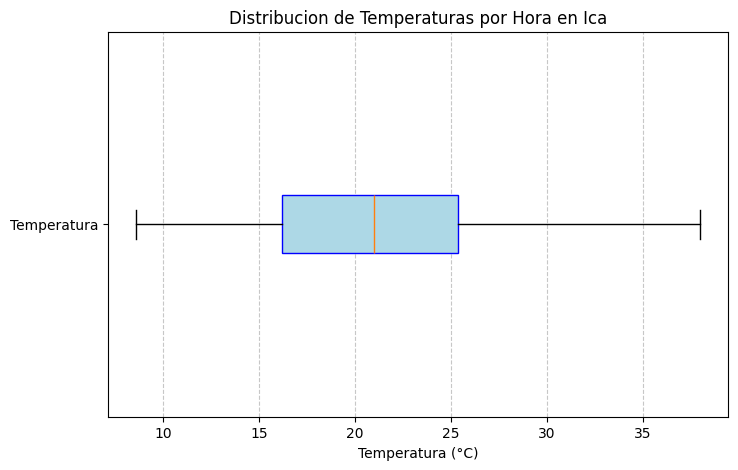

Archivo guardado correctamente: /content/temperaturas_ica.csv
Total de datos cargados: 52608


In [42]:
data = extract_data_from_url(url_con_parametros)

if not isinstance(data, dict):
    print(f"Error en Extract: {data}")
    
else:
    datos_transformados = diagrama_caja_bigotes(data)
    guardar_csv(datos_transformados)